# **Calculating VaR using Monte Carlo Simulation**

The Monte Carlo Simulation method is a flexible and forward-looking approach used to estimate Value at Risk (VaR) by modeling the uncertainty in portfolio returns. Under this method, a large number of potential future return scenarios are generated using assumed statistical properties of asset returns, such as expected returns, volatility, and correlations.

By simulating thousands of possible portfolio value paths over a specified time horizon, the distribution of potential losses is obtained. The VaR is then estimated as the quantile of this simulated loss distribution corresponding to the chosen confidence level. Unlike Parametric or Historical VaR, Monte Carlo Simulation can incorporate non-normal return distributions, complex portfolios, and non-linear risk factors, making it a powerful tool for advanced risk analysis.

In [4]:
# Importing Required Liabraries
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

years=15

end_date= dt.datetime.now()
start_date= end_date - dt.timedelta(days=365*years)

tickers= ['ICICIBANK.NS','HDFCBANK.NS','KOTAKBANK.NS','AXISBANK.NS','^NSEI']

In [ ]:
adj_close_df= pd.DataFrame()
for ticker in tickers:
  data=yf.download(ticker,start=start_date,end=end_date)
  adj_close_df[ticker]=data['Close']

log_retruns=np.log(adj_close_df/adj_close_df.shift(1))
log_retruns.dropna()

In [9]:
# Assuming that future returns are based on past retruns
# Calculating expected protfolio returns

def expected_return(weights,log_returns):
  return np.sum(log_returns.mean()*weights)

# Calculating portfolio standard deviation

def standard_deviation(weights,cov_matrix):
  variance= weights.T @ cov_matrix @ weights
  return np.sqrt(variance)

cov_matrix= log_retruns.cov()

In [10]:
portfolio_value = 1000000
weights = np.array([1/len(tickers)]*len(tickers))
portfolio_expected_return = expected_return(weights, log_retruns)
portfolio_std_dev = standard_deviation (weights, cov_matrix)

In [12]:
def random_z_score():
    return np.random.normal(0, 1)

days= 5

def scenario_gain_loss(portfolio_value, portfolio_std_dev, z_score, days):
    return portfolio_value*(portfolio_expected_return * days + portfolio_std_dev * z_score * np.sqrt(days))

In [13]:
# Run 10000 simulations

simulations = 10000
scenario_return = []

for i in range(simulations):
    z_score = random_z_score()
    scenario_return.append(scenario_gain_loss(portfolio_value, portfolio_std_dev, z_score, days))

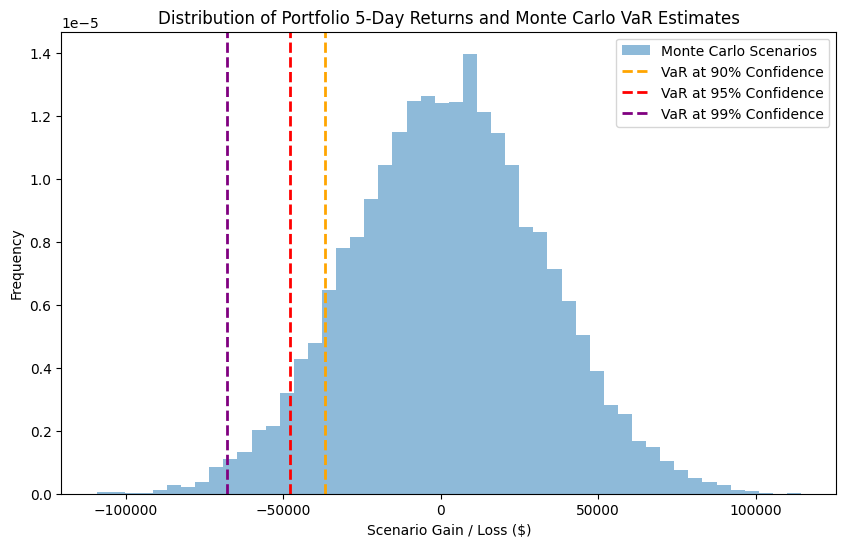

In [18]:
# Confidence levels and colors

confidence_levels = [0.90, 0.95, 0.99]
colors = {0.90: 'orange', 0.95: 'red', 0.99: 'purple'}

# Calculate Monte Carlo VaR for each confidence level

VaRs = {}
for cl in confidence_levels:
    VaRs[cl] = -np.percentile(scenario_return, (1 - cl) * 100)

# Plot histogram of Monte Carlo simulated returns

plt.figure(figsize=(10, 6))
plt.hist(scenario_return, bins=50, density=True, alpha=0.5, label='Monte Carlo Scenarios')

# Plot VaR lines
for cl, VaR in VaRs.items():
    plt.axvline(x=-VaR, color=colors[cl], linestyle='--', linewidth=2, label=f'VaR at {int(cl * 100)}% Confidence')

plt.xlabel('Scenario Gain / Loss ($)')
plt.ylabel('Frequency')
plt.title(f'Distribution of Portfolio {days}-Day Returns and Monte Carlo VaR Estimates')
plt.legend()
plt.show()